<h1 align="center">Quantiles extrêmes</h1>

Le but de ce notebook est de mettre en pratique les deux premières séances du cours sur la théorie des quantiles extrêmes. Nous allons donc nous intéresser dans un premier temps à une distribution unidimensionnelle pour l'instant. Fidèle à l'exemple évoqué en cours, nous allons appliquer ces résultats à l'historique de l'élévation du niveau de la *Seine* (Les données sont disponibles sur le site [DAHTI](https://dahiti.dgfi.tum.de/en/8965/) - Le site eaufrance est bien plus précis mais malheureusement ). Plus particulièrement, nous allons identifier le **domaine d'attraction** de cette distribution (*Fréchet*, *Weibull* ou *Gumbel*), estimer les **paramètres de la distribution limite**, et enfin estimer les **quantiles extrêmes** de cette distribution.

L'ajout de la notion de dépendance dans un modèle multidimensionnel est plus délicat, et nous y reviendrons dans un second temps, avec l'utilisation des **copules** dans un autre jupyter notebook.

# Récupération des données

Commençons par récupérer les données. 

Le fichier `provenance_donnees.md` permet de tracher chaque fichier de données utilisés pour ce projet.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns

In [2]:
seine = pd.read_csv("./data/DAHTI-8965-Seine.csv", sep=";")
# The first columb contains the date in the format "YYYY-MM-DD HH:MM:SS", we convert it to a datetime object
seine["datetime"] = pd.to_datetime(seine["datetime"], format="%Y-%m-%d %H:%M:%S")
# The second column contains the altitude of the water in meters, we convert it to a float
seine["wse"] = seine["wse"].astype(float)
# We compute the elevation from the min value
seine["elevation"] = seine["wse"] - seine["wse"].min()
seine.head()

,datetime,wse,wse_u,elevation
0,2008-07-23 07:55:10,69.449,0.013,1.228
1,2008-08-31 23:49:17,69.231,0.050,1.010
2,2008-10-10 15:43:25,69.045,0.049,0.824
3,2008-10-20 13:41:57,69.342,0.102,1.121
4,2008-10-30 11:40:28,69.122,0.030,0.901


In [3]:
# Summary of the table
seine.describe()

,datetime,wse,wse_u,elevation
count,605,605.000000,605.000000,605.000000
mean,2017-05-31 21:05:39.614876,69.517261,0.046288,1.296261
min,2008-07-23 07:55:10,68.221000,0.000000,0.000000
25%,2012-11-25 19:59:15,69.114000,0.013000,0.893000
50%,2017-03-31 08:04:56,69.323000,0.028000,1.102000
75%,2021-11-10 23:54:34,69.709000,0.066000,1.488000
max,2026-03-16 11:59:06,71.909000,0.470000,3.688000
std,NaN,0.637397,0.052181,0.637397


In [4]:
# Numer of nan values
seine.isna().sum() # Les données sont propres

datetime     0
wse          0
wse_u        0
elevation    0
dtype: int64

In [5]:
# Calcul de l'intervalle moyen entre les données - pour mieux évaluer le période de retour
time_diffs = seine["datetime"].diff().dropna()
mean_time_diff = time_diffs.mean()
print(f"Intervalle moyen entre les données: {mean_time_diff}")
print(f"Ecart type de l'intervalle entre les données: {time_diffs.std()}")

Intervalle moyen entre les données: 10 days 16:05:58.006622
Ecart type de l'intervalle entre les données: 3 days 22:12:24.025059


On a 605 données de l'élévation du niveau de la Seine, espacées d'environ 10 jours chacune. On voit bien que simplement calculer le quantile à 99% de ces données ne nous donnera pas une bonne estimation du quantile à 99% de la distribution limite, qui est ce qui nous intéresse pour l'analyse des extrêmes. C'est pourquoi nous allons utiliser la méthode des **maxima de blocs** pour estimer les paramètres de la distribution limite, et ensuite calculer les quantiles extrêmes à partir de cette distribution limite.

# Première analyse des données

In [6]:
mean, std = seine["elevation"].mean(), seine["elevation"].std()
print(f"Mean: {mean:.2f}, Std: {std:.2f}")

Mean: 1.30, Std: 0.64


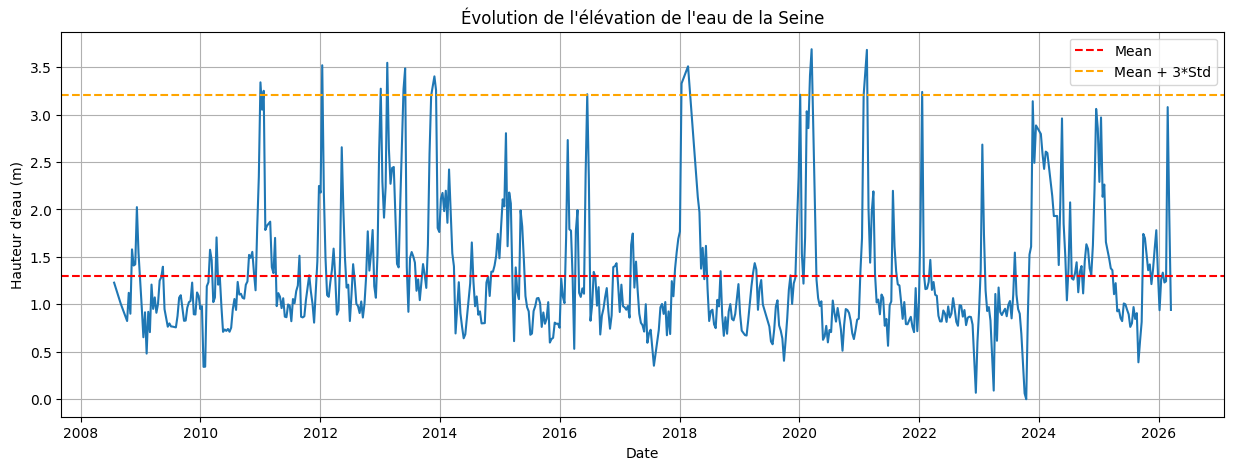

In [7]:
# Now draw a plot of the elevation of the water over time
plt.figure(figsize=(15, 5))
plt.plot(seine["datetime"], seine["elevation"])
# Plot the mean and the mean + 3*std
plt.axhline(mean, color="red", linestyle="--", label="Mean")
plt.axhline(mean + 3 * std, color="orange", linestyle="--", label="Mean + 3*Std")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Hauteur d'eau (m)")
plt.title("Évolution de l'élévation de l'eau de la Seine")
plt.grid()
plt.show()

La courbe dépasse de beaucoup la barre des $+3\sigma$, ce qui suggère que la distribution n'est pas gaussienne et possède une queue lourde. Nous allons vérifier cela dans la section suivante.

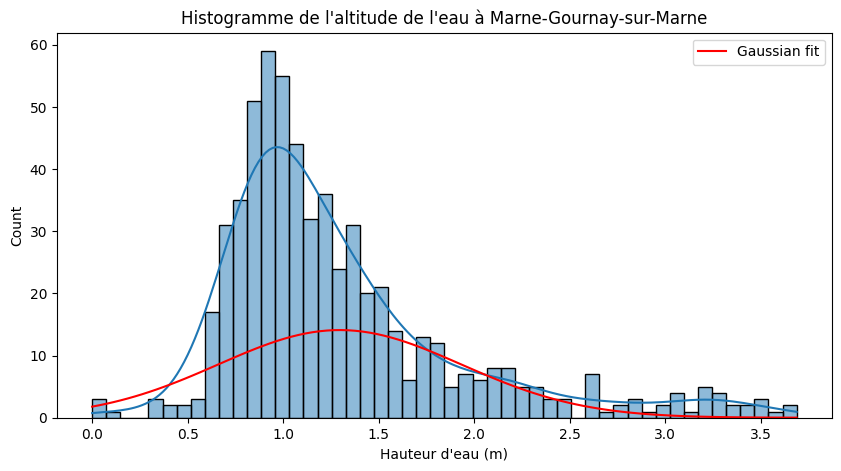

In [8]:
# Draw a histogram of the elevation of the water
plt.figure(figsize=(10, 5))
# Plot de l'histogramme de l'altitude de l'eau avec une courbe de densité
sns.histplot(seine["elevation"], bins=50, kde=True)
# Plot d'une gaussienne avec la même moyenne et écart-type que les données
x = np.linspace(seine["elevation"].min(), seine["elevation"].max(), 100)
plt.plot(x, stats.norm.pdf(x, mean, std) * len(seine["elevation"]) * (x[1] - x[0]), color="red", label="Gaussian fit")
plt.legend()
plt.xlabel("Hauteur d'eau (m)")
plt.title("Histogramme de l'altitude de l'eau à Marne-Gournay-sur-Marne")
plt.show()

On voit bien avec des deux figures que la distribution n'est pas gaussienne et possède une queue lourde. Elle appartiendrait donc au domaine d'attraction de Fréchet. Nous allons vérifier cela dans la section suivante.

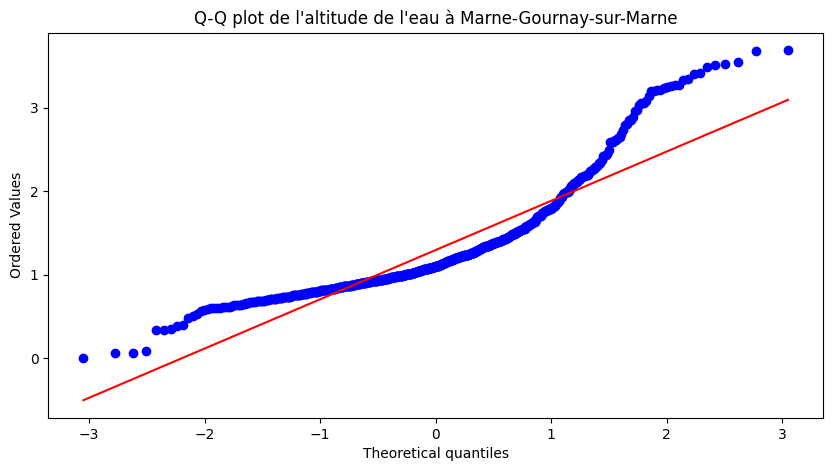

In [15]:
# Normale Q-Q plot
plt.figure(figsize=(10, 5))
stats.probplot(seine["elevation"], dist="norm", plot=plt)
plt.title("Q-Q plot de l'altitude de l'eau à Marne-Gournay-sur-Marne")
plt.show()

# Estimation des paramètres de la distribution limite

Effectuons un fit des données à une distribution de GEV (Generalized Extreme Value) pour estimer les paramètres de la distribution limite des maxima. Pour cela, nous allons utiliser la méthode `fit` de `scipy.stats.genextreme`.

On rassemble les données par maximum mensuel. 

In [9]:
# Calcul du maximum mensuel pour l'analyse des extrêmes
monthly_max = seine.groupby(seine["datetime"].dt.to_period("M"))["elevation"].max()

### Comment fonctionne mathématiquement `scipy.stats.genextreme.fit`



Dans `scipy.stats`, la loi `genextreme` (GEV) est paramétrée par un triplet $(c, \mu, \sigma)$ avec :



- $c$ : **paramètre de forme** (shape) — attention, en théorie des valeurs extrêmes on note souvent $\xi = -c$,

- $\mu \in \mathbb{R}$ : **paramètre de position** (location),

- $\sigma > 0$ : **paramètre d'échelle** (scale).



#### 1. Rappel : forme de la loi GEV



Pour $x$ tel que $1 + c\,z > 0$ avec $z = \dfrac{x - \mu}{\sigma}$, la fonction de répartition (CDF) de la GEV s’écrit :

$$

F(x; c, \mu, \sigma) = \exp\Big( -\big(1 + c\,z\big)^{-1/c} \Big),

$$



et la densité (PDF) correspondante est :

$$

f(x; c, \mu, \sigma) = \frac{1}{\sigma}\, \big(1 + c\,z\big)^{-1/c - 1} \exp\Big( -\big(1 + c\,z\big)^{-1/c} \Big),

$$

valable pour $1 + c\,z > 0$ et nulle sinon.



Lien avec la notation classique en EVT :

- on pose $\xi = -c$,

- $\xi>0$ : domaine de Fréchet (queue lourde),

- $\xi<0$ : domaine de Weibull (support supérieur borné),

- $\xi=0$ (limite $c \to 0$) : loi de Gumbel.



#### 2. Données et hypothèse de modèle



On dispose de données $x_1,\dots,x_n$ supposées i.i.d. suivant une loi GEV :

$$

X_i \sim \text{GEV}(c,\mu,\sigma), \quad i=1,\dots,n.

$$

En pratique, ce sont des **maxima de blocs** (annuels, mensuels, etc.), ce qui justifie l’utilisation de la GEV comme loi limite.



L’objectif de `genextreme.fit` est de trouver des estimations $(\hat c, \hat \mu, \hat \sigma)$ de $(c,\mu,\sigma)$ à partir de $x_1,\dots,x_n$.



#### 3. Fonction de vraisemblance



Sous l’hypothèse i.i.d., la **vraisemblance** est le produit des densités :

$$

L(c,\mu,\sigma; x_1,\dots,x_n) = \prod_{i=1}^n f(x_i; c,\mu,\sigma),

$$

avec $f$ la densité GEV ci-dessus. En pratique on travaille avec le **logarithme de la vraisemblance** :

$$

\ell(c,\mu,\sigma) = \log L(c,\mu,\sigma) = \sum_{i=1}^n \log f(x_i; c,\mu,\sigma).

$$

En insérant l’expression de $f$, on obtient (pour tous les $i$ tels que $1+c z_i>0$, où $z_i = (x_i - \mu)/\sigma$) :

$$

\ell(c,\mu,\sigma) = -n\log\sigma -\Big(1 + \frac{1}{c}\Big)\sum_{i=1}^n \log(1 + c z_i) - \sum_{i=1}^n (1 + c z_i)^{-1/c}.

$$

Si pour un triplet $(c,\mu,\sigma)$ donné il existe un indice $i$ tel que $1 + c z_i \le 0$, alors la vraisemblance est définie comme **nulle** (log-vraisemblance $= -\infty$).



#### 4. Principe de `fit` : maximum de vraisemblance numérique



`scipy.stats.genextreme.fit` renvoie des estimateurs du **maximum de vraisemblance** (EMV) :

$$

(\hat c, \hat \mu, \hat \sigma) = \arg\max_{c,\mu,\sigma} \; \ell(c,\mu,\sigma),

$$

sous les contraintes :

- $\sigma>0$,

- $1 + c (x_i - \mu)/\sigma > 0$ pour tout $i$.



Il n’existe pas de forme fermée simple des équations du maximum de vraisemblance (les dérivées partielles $\partial \ell / \partial c$, $\partial \ell / \partial \mu$, $\partial \ell / \partial \sigma$ ne se résolvent pas analytiquement). `scipy` utilise donc une **optimisation numérique** (méthode de type quasi-Newton / gradient, via les routines d’optimisation de `scipy.optimize`) :



1. Choix de valeurs initiales raisonnables (par exemple $\mu$ proche de la moyenne, $\sigma$ proche de l’écart-type, $c$ proche de 0).

2. Évaluation répétée de la log-vraisemblance $\ell(c,\mu,\sigma)$ et éventuellement de son gradient numérique.

3. Mise à jour itérative du triplet $(c,\mu,\sigma)$ jusqu’à convergence vers un maximum local (critère de tolérance sur la variation de $\ell$ ou des paramètres).



La fonction renvoie alors $(\hat c, \hat \mu, \hat \sigma)$. Dans le cadre de l’EVT, on convertit généralement $\hat c$ en $\hat \xi = -\hat c$.



#### 5. Interprétation des paramètres estimés



À partir des estimateurs :



- $\hat c$ (ou $\hat \xi = -\hat c$) quantifie la **queue** de la distribution :

  - $\hat \xi > 0$ : queue lourde (Fréchet),

  - $\hat \xi < 0$ : queue bornée (Weibull),

  - $\hat \xi \approx 0$ : comportement type Gumbel.

- $\hat \mu$ décrit une position typique des maxima de bloc.

- $\hat \sigma$ décrit la dispersion des maxima autour de $\hat \mu$.



Enfin, une fois le triplet estimé, on peut calculer rigoureusement les **quantiles de période de retour** $T$ via l’inverse de la CDF GEV :

$$

q_T = F^{-1}\big(1 - 1/T; \hat c, \hat \mu, \hat \sigma\big),

$$

ce qui correspond au niveau qui a une probabilité annuelle $1/T$ d’être dépassé (sous l’hypothèse que les blocs correspondent chacun à une année et que les maxima annuels sont i.i.d.).


In [10]:
# Fit GEV avec scipy: genextreme utilise la convention c = -xi
c, mu, sigma = stats.genextreme.fit(monthly_max.values)
xi = -c

print("Paramètres estimés de la loi limite (GEV):")
print(f"  xi (shape)   = {xi:.4f}")
print(f"  mu (location)= {mu:.4f}")
print(f"  sigma (scale)= {sigma:.4f}")

Paramètres estimés de la loi limite (GEV):
  xi (shape)   = 0.3587
  mu (location)= 1.1514
  sigma (scale)= 0.4059


Le paramètre $\xi$ est positif, ce qui suggère que la distribution limite appartient au domaine d'attraction de Fréchet. 

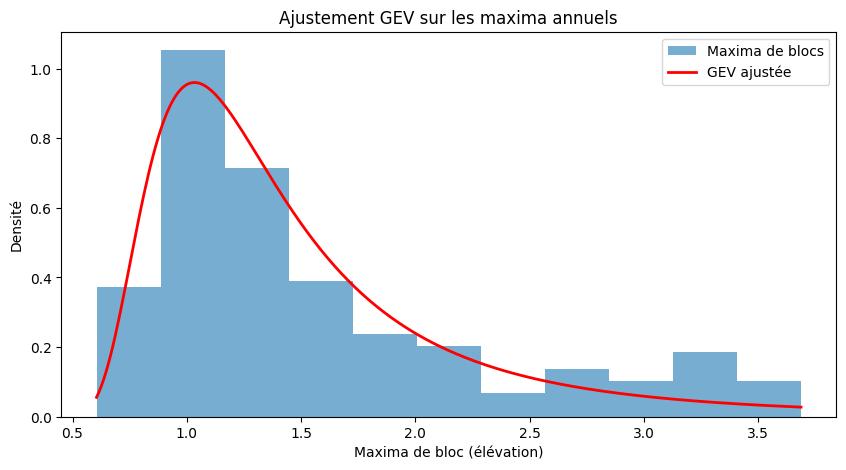

In [11]:
# Diagnostic visuel simple: histogramme des maxima + densité GEV ajustée
x = np.linspace(monthly_max.min(), monthly_max.max(), 300)
gev_pdf = stats.genextreme.pdf(x, c, loc=mu, scale=sigma)

plt.figure(figsize=(10, 5))
plt.hist(monthly_max, bins="auto", density=True, alpha=0.6, label="Maxima de blocs")
plt.plot(x, gev_pdf, "r-", lw=2, label="GEV ajustée")
plt.xlabel("Maxima de bloc (élévation)")
plt.ylabel("Densité")
plt.title("Ajustement GEV sur les maxima annuels")
plt.legend()
plt.show()

# Estimation des quantiles extrêmes

Ce qui nous permet d'estimer les quantiles extrêmes de la distribution limite, et ainsi d'estimer les niveaux d'élévation correspondant à des périodes de retour de 10 ans, 100 ans, etc.

In [12]:
# Estimation des quantiles extrêmes
alphas = [0.1, 0.01, 0.001, 0.0001]  # Probabilité de dépassement pour les périodes de retour
quantiles = stats.genextreme.ppf(1-np.array(alphas), c, loc=mu, scale=sigma)
print("Quantiles extrêmes estimés pour différents périodes de retour:")
for alpha, q in zip(alphas, quantiles):
    print(f"Quantile pour P(X > x) = {1-alpha:.4f}: {q:.2f} m")

Quantiles extrêmes estimés pour différents périodes de retour:
Quantile pour P(X > x) = 0.9000: 2.56 m
Quantile pour P(X > x) = 0.9900: 5.91 m
Quantile pour P(X > x) = 0.9990: 13.50 m
Quantile pour P(X > x) = 0.9999: 30.82 m


In [13]:
# Estimation des quantiles extrêmes - a du sens si on regroupe par months
return_periods = [10, 50, 100, 200, 500] # Périodes de retour en années
# Il faut faire une conversion puisque les données sont regroupées par mois, donc 12 données par an
return_periods_in_data_points = np.array(return_periods) * 12
quantiles = stats.genextreme.ppf(1 - 1/return_periods_in_data_points, c, loc=mu, scale=sigma)
print("Quantiles extrêmes estimés pour différents périodes de retour:")
for rp, q in zip(return_periods, quantiles):
    print(f"  Période de retour {rp} ans: élévation = {q:.2f} m")

Quantiles extrêmes estimés pour différents périodes de retour:
  Période de retour 10 ans: élévation = 6.31 m
  Période de retour 50 ans: élévation = 11.24 m
  Période de retour 100 ans: élévation = 14.41 m
  Période de retour 200 ans: élévation = 18.48 m
  Période de retour 500 ans: élévation = 25.66 m


Les quantiles estimées semblent largement exagérés. Cela doit être dû aux manques de données sur celles du site Dahti. Le site eaufrance est bien plus précis mais malheureusement les données ne sont pas disponibles actuellement en téléchargement.

L'idéal serait d'avoir suffisamment de données pour pouvoi faire une estimation sur quelques années puis un test sur l'ensemble des données restantes, pour vérifier la qualité de l'estimation. Malheureusement, avec seulement 605 données ne couvant que la dernière décennie, cela est difficilement envisageable.

# Saisonnalité

Étudions l'effet de saisonnalité qui est éventuellement à retirer des données. 

a (niveau moyen) = 1.2974
Amplitude saisonnière = 0.3811 m
Phase = -1.8531 rad


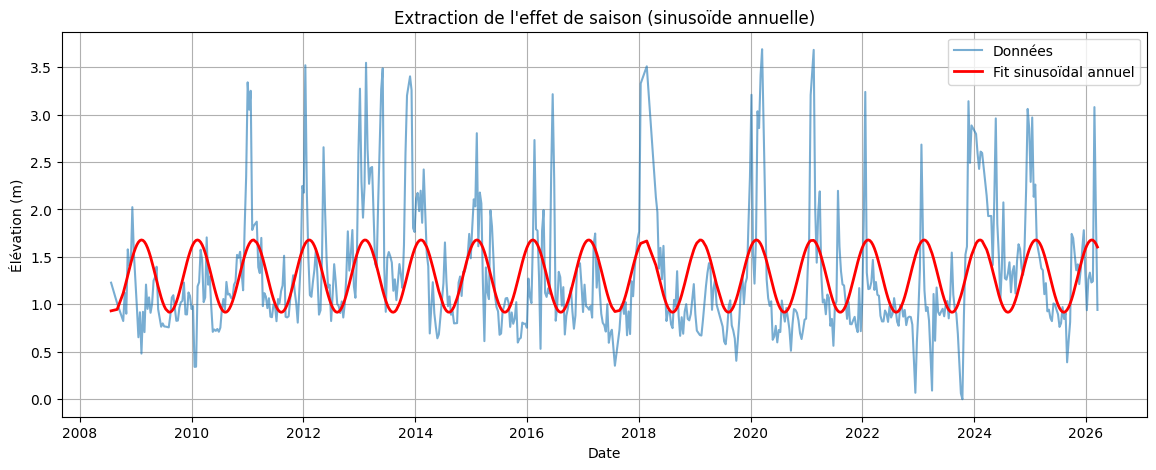

In [14]:
# Fit sinusoïdal (période annuelle) pour capturer la saisonnalité sur l'élévation
t_days = (seine["datetime"] - seine["datetime"].min()).dt.total_seconds() / 86400.0
y = seine["elevation"].values

T = 365.2425  # période annuelle en jours
omega = 2 * np.pi / T

# Modèle: y(t) = a + b*sin(omega*t) + d*cos(omega*t)
X = np.column_stack([
    np.ones_like(t_days),
    np.sin(omega * t_days),
    np.cos(omega * t_days)
])

a, b, d = np.linalg.lstsq(X, y, rcond=None)[0]

# Effet saisonnier estimé (centré) + signal ajusté complet
seasonal_effect = b * np.sin(omega * t_days) + d * np.cos(omega * t_days)
seine["seasonal_effect"] = seasonal_effect
seine["seasonal_fit"] = a + seasonal_effect
seine["elevation_deseasonalized"] = seine["elevation"] - seasonal_effect

# Paramètres interprétables
amplitude = np.sqrt(b**2 + d**2)
phase = np.arctan2(d, b)  # pour y = a + A*sin(omega*t + phase)

print(f"a (niveau moyen) = {a:.4f}")
print(f"Amplitude saisonnière = {amplitude:.4f} m")
print(f"Phase = {phase:.4f} rad")

# Visualisation
plt.figure(figsize=(14, 5))
plt.plot(seine["datetime"], seine["elevation"], label="Données", alpha=0.6)
plt.plot(seine["datetime"], seine["seasonal_fit"], color="red", lw=2, label="Fit sinusoïdal annuel")
plt.xlabel("Date")
plt.ylabel("Élévation (m)")
plt.title("Extraction de l'effet de saison (sinusoïde annuelle)")
plt.legend()
plt.grid(True)
plt.show()